In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

import joblib

In [2]:
df = pd.read_csv("../data/processed/model_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (504063, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,98702677,6,7,397,11595,379,0,66.166667,153.284594,...,20,18961.0,0.0,18961,18961,98600000.0,0.0,98600000,98600000,DoS
1,80,2857734,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2,80,24576401,4,0,24,0,6,6,6.000000,0.000000,...,20,1007.0,0.0,1007,1007,24600000.0,0.0,24600000,24600000,DDoS
3,45007,4,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,22,10463253,20,33,2008,2745,640,0,100.400000,141.914133,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Brute Force


In [3]:
X = df.drop("Label", axis=1)
y = df["Label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (504063, 78)
Target shape: (504063,)


In [4]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")

for label, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} -> {encoded}")

Encoded classes:
BENIGN -> 0
Bot -> 1
Brute Force -> 2
DDoS -> 3
DoS -> 4
PortScan -> 5
Web Attack -> 6


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (403250, 78)
Testing set: (100813, 78)


In [6]:
X_train_smote_input = X_train.copy()

train_medians = X_train_smote_input.median()

X_train_smote_input = X_train_smote_input.fillna(train_medians)

X_test_clean = X_test.fillna(train_medians)

print("Training NaNs:", X_train_smote_input.isna().sum().sum())
print("Testing NaNs:", X_test_clean.isna().sum().sum())

Training NaNs: 0
Testing NaNs: 0


In [7]:
smote = SMOTE(
    sampling_strategy={
        1: 8500,   # Bot
        6: 8500    # Web Attack
    },
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_smote_input,
    y_train
)

print("Original training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Original training shape: (403250, 78)
SMOTE training shape: (418150, 78)

Class distribution after SMOTE:
0    119997
1      8500
2      8498
3     80000
4    120000
5     72655
6      8500
Name: count, dtype: int64


In [8]:
smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

smote_model.fit(X_train_smote, y_train_smote)

print("SMOTE Random Forest trained successfully.")

SMOTE Random Forest trained successfully.


In [9]:
y_pred_smote = smote_model.predict(X_test_clean)

print(classification_report(
    y_test,
    y_pred_smote,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29999
         Bot       0.94      0.96      0.95       391
 Brute Force       0.98      0.93      0.96      2124
        DDoS       1.00      1.00      1.00     20000
         DoS       1.00      1.00      1.00     30000
    PortScan       1.00      1.00      1.00     18164
  Web Attack       0.39      0.67      0.49       135

    accuracy                           1.00    100813
   macro avg       0.90      0.94      0.91    100813
weighted avg       1.00      1.00      1.00    100813



In [10]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": smote_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
63,Subflow Fwd Bytes,0.057209
6,Fwd Packet Length Max,0.046627
18,Flow IAT Max,0.036675
4,Total Length of Fwd Packets,0.033588
52,Average Packet Size,0.032953
54,Avg Bwd Segment Size,0.032323
39,Max Packet Length,0.031669
23,Fwd IAT Max,0.031267
40,Packet Length Mean,0.030647
53,Avg Fwd Segment Size,0.029645


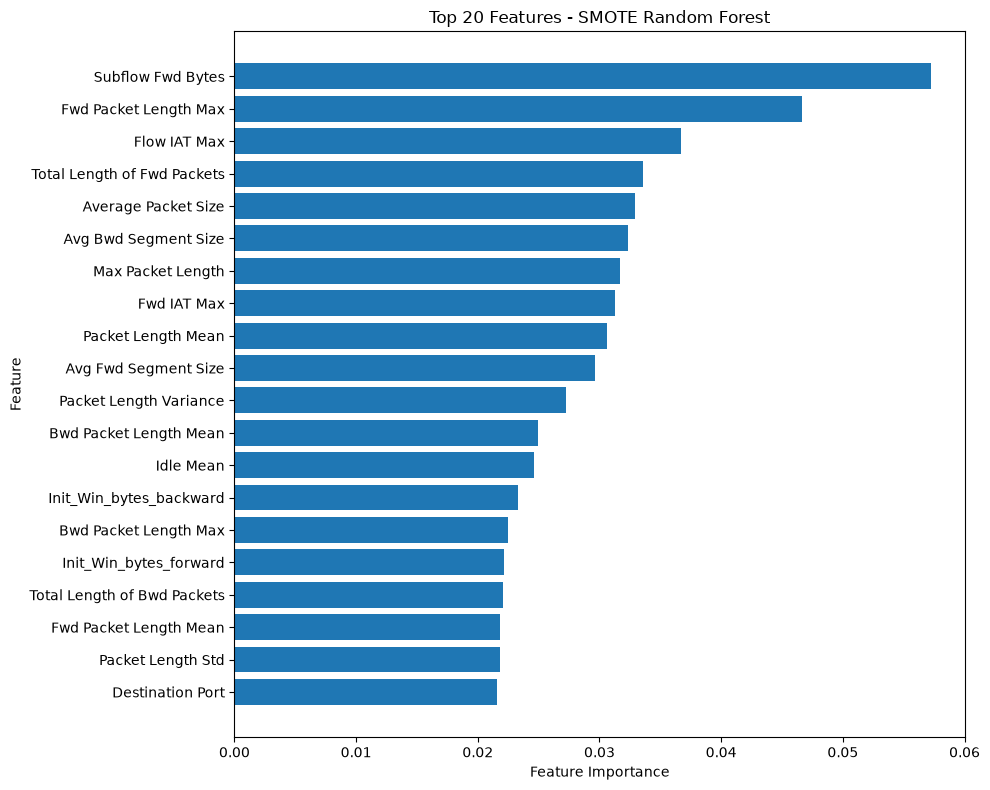

In [11]:
top_features = feature_importance.head(20).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - SMOTE Random Forest")

plt.tight_layout()
plt.show()

In [12]:
n_estimators_values = [50, 100, 150, 200]

tuning_results = []

for n in n_estimators_values:

    print(f"Training Random Forest with {n} trees...")

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_smote, y_train_smote)

    predictions = rf.predict(X_test_clean)

    tuning_results.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_precision": precision_score(
            y_test, predictions, average="macro"
        ),
        "macro_recall": recall_score(
            y_test, predictions, average="macro"
        ),
        "macro_f1": f1_score(
            y_test, predictions, average="macro"
        ),
        "web_attack_recall": recall_score(
            y_test,
            predictions,
            labels=[6],
            average=None
        )[0]
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df

Training Random Forest with 50 trees...
Training Random Forest with 100 trees...
Training Random Forest with 150 trees...
Training Random Forest with 200 trees...


,n_estimators,accuracy,macro_precision,macro_recall,macro_f1,web_attack_recall
0,50,0.996935,0.901797,0.938361,0.914881,0.674074
1,100,0.996985,0.901532,0.937272,0.914262,0.666667
2,150,0.996994,0.902724,0.941788,0.916502,0.696296
3,200,0.996985,0.901659,0.938751,0.914928,0.674074


In [13]:
X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_train_base.shape)
print("Validation set:", X_val.shape)

Training subset: (322600, 78)
Validation set: (80650, 78)


In [14]:
train_medians = X_train_base.median()

X_train_base_clean = X_train_base.fillna(train_medians)
X_val_clean = X_val.fillna(train_medians)

print("Training NaNs:", X_train_base_clean.isna().sum().sum())
print("Validation NaNs:", X_val_clean.isna().sum().sum())

Training NaNs: 0
Validation NaNs: 0


In [15]:
smote_tune = SMOTE(
    sampling_strategy={
        1: 8500,
        6: 8500
    },
    random_state=42
)

X_train_tune, y_train_tune = smote_tune.fit_resample(
    X_train_base_clean,
    y_train_base
)

print("Training before SMOTE:", X_train_base.shape)
print("Training after SMOTE:", X_train_tune.shape)

Training before SMOTE: (322600, 78)
Training after SMOTE: (337920, 78)


In [16]:
tuned_150_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

tuned_150_model.fit(X_train_tune, y_train_tune)

y_val_pred = tuned_150_model.predict(X_val_clean)

print(classification_report(
    y_val,
    y_val_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     23999
         Bot       0.95      0.97      0.96       312
 Brute Force       0.99      0.93      0.96      1700
        DDoS       1.00      1.00      1.00     16000
         DoS       1.00      1.00      1.00     24000
    PortScan       1.00      1.00      1.00     14531
  Web Attack       0.42      0.79      0.55       108

    accuracy                           1.00     80650
   macro avg       0.91      0.95      0.92     80650
weighted avg       1.00      1.00      1.00     80650



In [17]:
max_depth_values = [None, 20, 30]

depth_results = []

for depth in max_depth_values:

    print(f"Training model with max_depth={depth}...")

    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_tune, y_train_tune)

    predictions = rf.predict(X_val_clean)

    depth_results.append({
        "max_depth": depth,
        "accuracy": accuracy_score(y_val, predictions),
        "macro_precision": precision_score(
            y_val, predictions, average="macro"
        ),
        "macro_recall": recall_score(
            y_val, predictions, average="macro"
        ),
        "macro_f1": f1_score(
            y_val, predictions, average="macro"
        ),
        "web_attack_recall": recall_score(
            y_val,
            predictions,
            labels=[6],
            average=None
        )[0],
        "web_attack_f1": f1_score(
            y_val,
            predictions,
            labels=[6],
            average=None
        )[0]
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

Training model with max_depth=None...
Training model with max_depth=20...
Training model with max_depth=30...


,max_depth,accuracy,macro_precision,macro_recall,macro_f1,web_attack_recall,web_attack_f1
0,NaN,0.997173,0.907815,0.954267,0.922868,0.787037,0.546624
1,20.0,0.997024,0.903436,0.965555,0.920887,0.879630,0.542857
2,30.0,0.997235,0.908266,0.958387,0.924097,0.814815,0.553459


In [18]:
leaf_values = [1, 2, 4]

leaf_results = []

for leaf in leaf_values:

    print(f"Training model with min_samples_leaf={leaf}...")

    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_tune, y_train_tune)

    predictions = rf.predict(X_val_clean)

    leaf_results.append({
        "min_samples_leaf": leaf,
        "accuracy": accuracy_score(y_val, predictions),
        "macro_precision": precision_score(
            y_val, predictions, average="macro"
        ),
        "macro_recall": recall_score(
            y_val, predictions, average="macro"
        ),
        "macro_f1": f1_score(
            y_val, predictions, average="macro"
        ),
        "web_attack_recall": recall_score(
            y_val,
            predictions,
            labels=[6],
            average=None
        )[0],
        "web_attack_f1": f1_score(
            y_val,
            predictions,
            labels=[6],
            average=None
        )[0]
    })

leaf_results_df = pd.DataFrame(leaf_results)

leaf_results_df


Training model with min_samples_leaf=1...
Training model with min_samples_leaf=2...
Training model with min_samples_leaf=4...


,min_samples_leaf,accuracy,macro_precision,macro_recall,macro_f1,web_attack_recall,web_attack_f1
0,1,0.997024,0.903436,0.965555,0.920887,0.879630,0.542857
1,2,0.996875,0.903567,0.966668,0.920047,0.898148,0.537396
2,4,0.996516,0.900912,0.970742,0.918364,0.935185,0.535809


In [19]:
final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_smote,
    y_train_smote
)

print("Final model trained successfully.")

Final model trained successfully.


In [20]:
y_pred_final = final_model.predict(X_test_clean)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29999
         Bot       0.94      0.97      0.95       391
 Brute Force       0.99      0.91      0.95      2124
        DDoS       1.00      1.00      1.00     20000
         DoS       1.00      1.00      1.00     30000
    PortScan       1.00      1.00      1.00     18164
  Web Attack       0.38      0.89      0.53       135

    accuracy                           1.00    100813
   macro avg       0.90      0.97      0.92    100813
weighted avg       1.00      1.00      1.00    100813



In [21]:
final_accuracy = accuracy_score(y_test, y_pred_final)
final_macro_f1 = f1_score(y_test, y_pred_final, average="macro")
final_macro_recall = recall_score(y_test, y_pred_final, average="macro")

print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Final Macro Recall: {final_macro_recall:.4f}")
print(f"Final Macro F1: {final_macro_f1:.4f}")

Final Accuracy: 0.9968
Final Macro Recall: 0.9657
Final Macro F1: 0.9186


In [22]:
cm_final = confusion_matrix(y_test, y_pred_final)

print("Final Confusion Matrix:")
print(cm_final)

Final Confusion Matrix:
[[29935    26     1     1    22    12     2]
 [   13   378     0     0     0     0     0]
 [    4     0  1929     0     0     0   191]
 [    7     0     0 19993     0     0     0]
 [    8     0     3     0 29989     0     0]
 [    8     0     0     0     7 18148     1]
 [    3     0    11     0     1     0   120]]


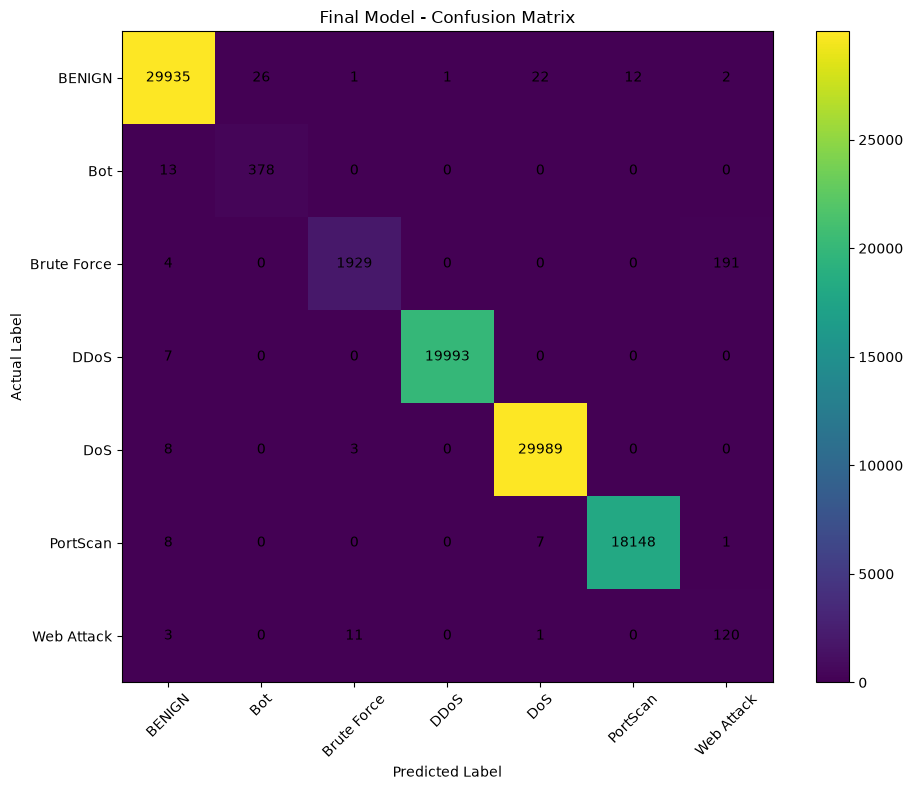

In [23]:
plt.figure(figsize=(10, 8))

plt.imshow(cm_final)

plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        plt.text(
            j,
            i,
            cm_final[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
## Conclusion

The Random Forest model was optimized to improve intrusion detection performance, particularly for minority attack classes.

The baseline Random Forest achieved 99.73% accuracy but detected only 28.1% of Web Attack samples. Class weighting did not improve minority-class detection, with Web Attack recall decreasing to 25.2%.

Targeted SMOTE was then applied to increase the representation of the Bot and Web Attack classes. This improved Web Attack recall substantially.

Hyperparameter tuning was subsequently performed using a validation set. The final model used 150 trees, a maximum tree depth of 20, and a minimum leaf size of 1.

The final model achieved 99.68% accuracy, 96.57% macro recall, and 91.86% macro F1 on the untouched test set. Most importantly, Web Attack recall increased to 88.89%.

Although overall accuracy decreased slightly compared with the baseline model, the significant improvement in minority-class detection makes the tuned SMOTE Random Forest more suitable for the intrusion detection system.